In [149]:
library(lme4)
library(emmeans)
library(dplyr)


df_full <- read.csv("PCA_error_projectile_experiment _S1-projectile_experiment_S2-projectile_experiment_S1_3.0M-projectile_experiment 1_S2_3.0M-projectile_experiment 1_speed_neg3_0_neg2_0_0_0.csv")

df_full$ppid_full <- factor(df_full$ppid_full)
df_full$speed_label <- factor(df_full$speed_label)
df_full$target_x_label <- factor(df_full$target_x_label)
df_full$phase <- factor(df_full$phase)

In [ ]:
#### GENERALIZATION ANALYSIS

[1] "Working directory: C:/Users/jacob/water_current_MA/data/dual_generalization"
[1] "-2"


Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm_bc ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect        df         F p.value
1       target_x_label 3, 522.18 33.29 ***   <.001
2                phase 1, 522.46 44.36 ***   <.001
3 target_x_label:phase 3, 131.74      1.85    .141
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -13.5 2.03 522    -17.5    -9.55  -6.660  <.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -10.72 5.05 121    -20.7   -0.718  -2.122  0.0359

target_x_label = L60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -7.02 5.04 120    -17.0    2.952  -1.394  0.1660

target_x_label = R30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -16.46 5.07 122    -26.5   -6.418  -3.245  0.0015

target_x_label = R60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -19.99 5.06 121    -30.0   -9.979  -3.952  0.0001

Degrees-o

Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm_bc ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect        df          F p.value
1       target_x_label 3, 499.28  98.13 ***   <.001
2                phase 1, 501.06 150.07 ***   <.001
3 target_x_label:phase 3, 133.91   9.72 ***   <.001
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -24.7 2.02 501    -28.7    -20.8 -12.248  <.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -14.6 4.94 123    -24.4    -4.82  -2.955  0.0037

target_x_label = L60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -13.1 4.95 123    -22.9    -3.32  -2.651  0.0091

target_x_label = R30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -35.6 5.01 128    -45.5   -25.67  -7.101  <.0001

target_x_label = R60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -35.6 4.95 124    -45.4   -25.79  -7.191  <.0001

Degrees-o

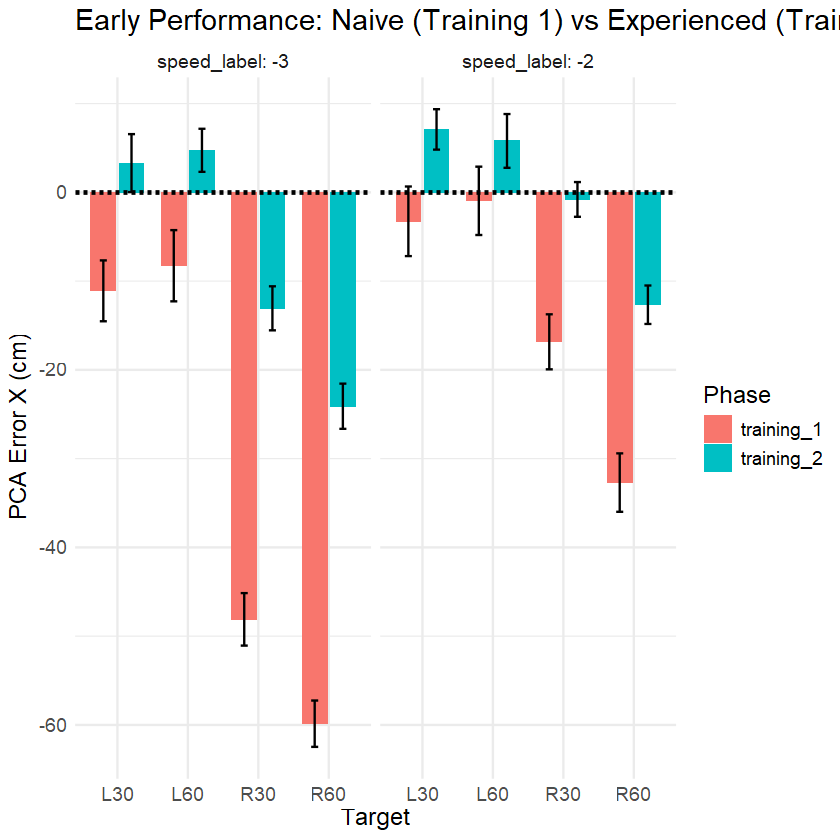

In [181]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/dual_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

df_early_late <- read.csv("early_late_phase_PCA_error_projectile_experiment _S1-projectile_experiment_etc_speed_neg3_0_neg2_0.csv")

# Ensure factors
df_early_late$ppid_full <- factor(df_early_late$ppid_full)
df_early_late$speed_label <- factor(df_early_late$speed_label)
df_early_late$target_x_label <- factor(df_early_late$target_x_label)
df_early_late$phase <- factor(df_early_late$phase)
df_early_late$trial_set <- factor(df_early_late$trial_set)



# leave out late trials
df_early <- df_early_late[df_early_late$trial_set == "early", ]
speeds_list <- unique(df_early$speed_label)

for (s in speeds_list) {

  print(s)
  
  df_subset <- df_early[df_early$speed_label == s,]
  df_subset <- droplevels(df_subset) 
    
  mm_gen <- afex::mixed(PCA_error_X_cm_bc ~ target_x_label * phase + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))
}


library(ggplot2)
library(dplyr)

# Calculate means and standard errors for plotting
plot_data <- df_early %>%
  group_by(speed_label, phase, target_x_label) %>%
  summarise(
    mean_error = mean(PCA_error_X_cm_bc, na.rm = TRUE),
    se_error = sd(PCA_error_X_cm, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Create the plot
ggplot(plot_data, aes(x = target_x_label, y = mean_error, fill = phase)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_errorbar(aes(ymin = mean_error - se_error, ymax = mean_error + se_error),
                position = position_dodge(width = 0.8), width = 0.2) +
  facet_wrap(~ speed_label, labeller = label_both) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) + # 0 line
  theme_minimal() +
  labs(
    title = "Early Performance: Naive (Training 1) vs Experienced (Training 2)",
    x = "Target",
    y = "PCA Error X (cm)",
    fill = "Phase"
  ) +
  theme(text = element_text(size = 14))

In [ ]:
# OVERALL LEARNING (EARLY VS LATE) ANALYSIS

[1] "Working directory: C:/Users/jacob/water_current_MA/data/dual_generalization"
[1] "-2"


Contrasts set to contr.sum for the following variables: target_x_label, phase, trial_set, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm_bc ~ target_x_label * phase * trial_set + (1 | 
Model:     ppid_full)
Data: df_subset
                          Effect         df         F p.value
1                 target_x_label 3, 1086.39 36.61 ***   <.001
2                          phase 1, 1086.48 23.09 ***   <.001
3                      trial_set 1, 1086.51 43.37 ***   <.001
4           target_x_label:phase  3, 130.80   5.44 **    .001
5       target_x_label:trial_set 3, 1086.39  9.64 ***   <.001
6                phase:trial_set 1, 1086.51 32.73 ***   <.001
7 target_x_label:phase:trial_set 3, 1086.39      0.97    .405
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -6.13 1.28 1087    -8.63    -3.63  -4.805  <.0001

Results are averaged over the levels of: target_x_label, trial_set 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -6.17 3.33 106   -12.78    0.441  -1.850  0.0671

target_x_label = L60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2     2.89 3.33 105    -3.71    9.487   0.868  0.3876

target_x_label = R30:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -10.56 3.34 106   -17.17   -3.942  -3.164  0.0020

target_x_label = R60:
 contrast                estimate   SE  df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -10.68 3.34 106   -17.29   -4.066  -3.202  0.00

Contrasts set to contr.sum for the following variables: target_x_label, phase, trial_set, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: PCA_error_X_cm_bc ~ target_x_label * phase * trial_set + (1 | 
Model:     ppid_full)
Data: df_subset
                          Effect         df          F p.value
1                 target_x_label 3, 1062.82 158.24 ***   <.001
2                          phase 1, 1063.43  92.56 ***   <.001
3                      trial_set 1, 1063.30  82.20 ***   <.001
4           target_x_label:phase  3, 124.91  15.64 ***   <.001
5       target_x_label:trial_set 3, 1062.81  10.77 ***   <.001
6                phase:trial_set 1, 1063.39  90.33 ***   <.001
7 target_x_label:phase:trial_set 3, 1062.78     3.21 *    .022
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions



 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -12.3 1.28 1063    -14.8     -9.8  -9.620  <.0001

Results are averaged over the levels of: target_x_label, trial_set 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
target_x_label = L30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -5.20 3.48 94.4   -12.10     1.71  -1.494  0.1386

target_x_label = L60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2    -2.41 3.48 94.0    -9.31     4.49  -0.694  0.4894

target_x_label = R30:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -16.39 3.49 95.8   -23.32    -9.45  -4.690  <.0001

target_x_label = R60:
 contrast                estimate   SE   df lower.CL upper.CL t.ratio p.value
 training_1 - training_2   -25.24 3.48 94.3   -32.15   -18.34  -7.2

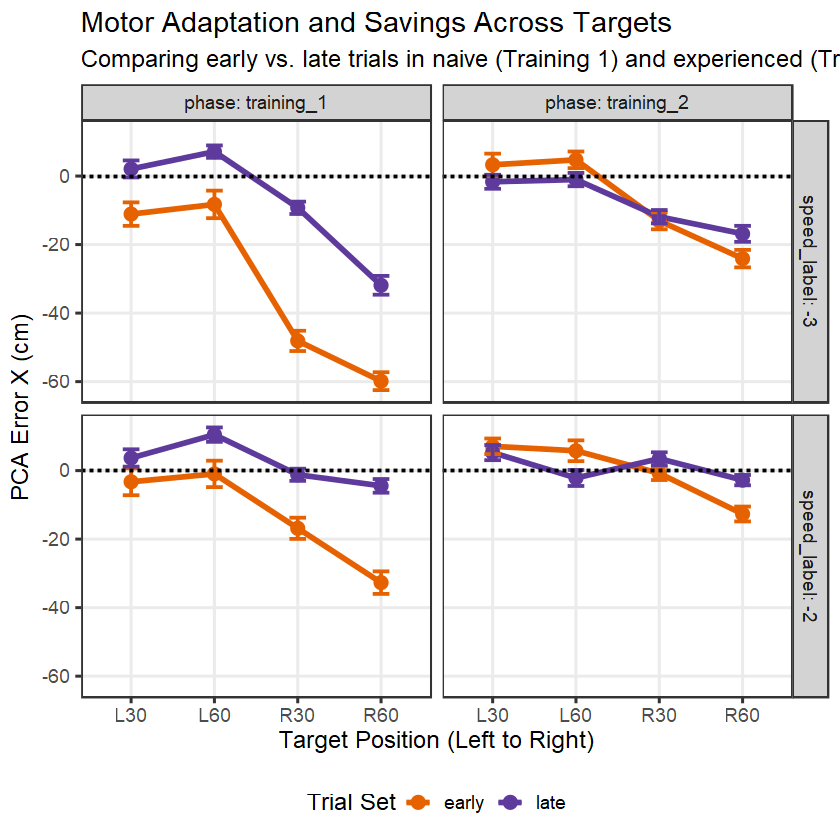

In [183]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/dual_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

for (s in speeds_list) {
  
  print(s)
  
  df_subset <- df_early_late[df_early_late$speed_label == s,]
  df_subset <- droplevels(df_subset) 
    
  mm_gen <- afex::mixed(PCA_error_X_cm_bc ~ target_x_label * phase * trial_set + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_set <- emmeans(mm_gen, ~ trial_set)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  emm_phase_trial <- emmeans(mm_gen, ~ trial_set | phase)
  emm_3way <- emmeans(mm_gen, ~ trial_set | phase * target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))
  print(pairs(emm_by_set, adjust = "holm", infer = TRUE))
  print(pairs(emm_3way, adjust = "holm", infer = TRUE))

}

# GENERATE THE PLOTS ---

# Calculate means and standard errors
plot_data <- df_dual %>%
  group_by(speed_label, phase, trial_set, target_x_label) %>%
  summarise(
    mean_error = mean(PCA_error_X_cm_bc, na.rm = TRUE),
    se_error = sd(PCA_error_X_cm, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Create the 3-Way Interaction Plot
adaptation_plot <- ggplot(plot_data, aes(x = target_x_label, y = mean_error, color = trial_set, group = trial_set)) +
  # Draw the lines connecting early to late
  geom_line(linewidth = 1.2) +
  # Add the points with error bars
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_error - se_error, ymax = mean_error + se_error), width = 0.2, linewidth = 0.8) +
  # Create a grid: Speeds on the Y axis, Phases on the X axis
  facet_grid(speed_label ~ phase, labeller = label_both) + 
  # Add the "perfect aim" baseline
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  # Clean up the theme
  theme_bw(base_size = 14) +
  scale_color_manual(values = c("early" = "#E66100", "late" = "#5D3A9B")) +
  labs(
    title = "Motor Adaptation and Savings Across Targets",
    subtitle = "Comparing early vs. late trials in naive (Training 1) and experienced (Training 2) phases",
    x = "Target Position (Left to Right)", 
    y = "PCA Error X (cm)", 
    color = "Trial Set"
  ) +
  theme(
    legend.position = "bottom",
    strip.background = element_rect(fill = "lightgray"),
    panel.grid.minor = element_blank()
  )

# Display the plot
print(adaptation_plot)


In [ ]:
### WASHOUT ANALYSIS

In [121]:
names(df_full)

[1] "experiment"               "ppid_full"               
 [3] "speed_label"              "target_x_label"          
 [5] "target_position_x_cm"     "target_position_z_cm"    
 [7] "trial_num"                "phase"                   
 [9] "phase_target_trial_num"   "trial_num_target"        
[11] "cycle_target_num"         "cycle_TargetxPhase_num"  
[13] "launch_deviation"         "launch_Speed"            
[15] "ball_dist_to_center_cm"   "lateral_error_x_cm"      
[17] "depth_error_z_cm"         "target_hit"              
[19] "water_speed_binary"       "water_speed_m_s"         
[21] "sign_label"               "set_order"               
[23] "min_pos_from_target_x_cm" "min_pos_from_target_z_cm"
[25] "target_angle_90"          "pc_vector_1_angle"       
[27] "pc_vector_1_pca_center_x" "pc_vector_1_pca_center_z"
[29] "pc_vector_1_c_X"          "pc_vector_1_c_Z"         
[31] "pc_rad"                   "centered_x"              
[33] "centered_z"               "unrotated_x"             
[35] "unrotated_z"              "tgt_centered_x"          
[37] "tgt_centered_z"           "tgt_unrotated_x"         
[39] "tgt_unrotated_z"          "PCA_error_X_cm"          
[41] "PCA_error_Z_cm"           "PCA_error_X_cm_mean"     
[43] "PCA_error_X_cm_bc"

In [177]:
library(afex)
library(emmeans) 

setwd("C:/Users/jacob/water_current_MA/data/dual_generalization")
dir <- getwd()
print(paste("Working directory:", dir))

df_washout <- df_full[df_full$phase == 'washout_1' | df_full$phase == 'washout_2' & df_full$water_speed_binary == 0, ]


for (s in speeds_list) {

  print(s)
  
  df_subset <- df_washout[df_washout$speed_label == s,]
  df_subset <- droplevels(df_subset)
  
  df_subset <- df_subset %>% mutate(trial_centered = phase_target_trial_num - 1)
    
  mm_gen <- afex::mixed(launch_deviation ~ target_x_label * phase + (1|ppid_full),
                        data = df_subset, method = "S")
  
  print(afex::nice(mm_gen))
  
  emm_mm_gen <- emmeans(mm_gen, ~ phase)
  emm_by_target <- emmeans(mm_gen, ~ phase | target_x_label)
  
  print(pairs(emm_mm_gen, infer = TRUE))
  print(pairs(emm_by_target, adjust = "holm", infer = TRUE))

}


[1] "Working directory: C:/Users/jacob/water_current_MA/data/dual_generalization"
[1] "-2"


Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: launch_deviation ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect         df          F p.value
1       target_x_label 3, 3982.99  14.55 ***   <.001
2                phase 1, 3983.00 599.39 ***   <.001
3 target_x_label:phase  3, 114.63  13.98 ***   <.001
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 4025' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 4025)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 4025' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 4025)' or larger];
but be warned that this may result in large computation time and memory use.

NOTE: Results may be misleading due to involvement in interactions

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 4025' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 4025)' or larger];
but be warned that this may result in large computation time and mem

 contrast              estimate    SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -11.9 0.485 Inf     -12.8     -10.9 -24.482  <.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: asymptotic 
Confidence level used: 0.95 
target_x_label = L30:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2   -14.19 1.59 Inf     -17.3    -11.06  -8.899  <.0001

target_x_label = L60:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2   -15.80 1.60 Inf     -18.9    -12.66  -9.851  <.0001

target_x_label = R30:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -9.08 1.60 Inf     -12.2     -5.94  -5.661  <.0001

target_x_label = R60:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -8.40 1.60 Inf     -11.5     -5.27  -5.265  <.0001

Degrees-of

Contrasts set to contr.sum for the following variables: target_x_label, phase, ppid_full



Mixed Model Anova Table (Type 3 tests, S-method)

Model: launch_deviation ~ target_x_label * phase + (1 | ppid_full)
Data: df_subset
                Effect         df          F p.value
1       target_x_label 3, 3979.00  30.54 ***   <.001
2                phase 1, 3979.01 762.83 ***   <.001
3 target_x_label:phase  3, 122.89  22.83 ***   <.001
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '+' 0.1 ' ' 1


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 4021' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 4021)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 4021' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 4021)' or larger];
but be warned that this may result in large computation time and memory use.

NOTE: Results may be misleading due to involvement in interactions

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 4021' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 4021)' or larger];
but be warned that this may result in large computation time and mem

 contrast              estimate    SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -12.9 0.469 Inf     -13.9       -12 -27.619  <.0001

Results are averaged over the levels of: target_x_label 
Degrees-of-freedom method: asymptotic 
Confidence level used: 0.95 
target_x_label = L30:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2   -13.54 1.44 Inf     -16.4    -10.72  -9.427  <.0001

target_x_label = L60:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2   -19.71 1.41 Inf     -22.5    -16.95 -14.014  <.0001

target_x_label = R30:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2   -11.93 1.41 Inf     -14.7     -9.18  -8.484  <.0001

target_x_label = R60:
 contrast              estimate   SE  df asymp.LCL asymp.UCL z.ratio p.value
 washout_1 - washout_2    -6.59 1.44 Inf      -9.4     -3.77  -4.587  <.0001

Degrees-of

In [167]:
df_subset

,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_target_trial_num,trial_num_target,⋯,unrotated_z,tgt_centered_x,tgt_centered_z,tgt_unrotated_x,tgt_unrotated_z,PCA_error_X_cm,PCA_error_Z_cm,PCA_error_X_cm_mean,PCA_error_X_cm_bc,trial_centered
,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<fct>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
17241,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,203,washout_1,1,89,⋯,122.6635315,-8.9352781,5.019826,9.226709,-4.461580,-82.4697131,127.1251110,0.9369059,-83.406619,0
17242,S1_3.0M-projectile_experiment 1,1_neg3,-3,R30,30,140,204,washout_1,1,89,⋯,-2.9278575,-6.7015013,7.220195,9.044805,-3.902927,-34.8081681,0.9750694,-11.8490010,-22.959167,0
17243,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,205,washout_1,2,90,⋯,-7.7250309,-8.9352781,5.019826,9.226709,-4.461580,-31.3580677,-3.2634514,0.9369059,-32.294974,1
17244,S1_3.0M-projectile_experiment 1,1_neg3,-3,R30,30,140,206,washout_1,2,90,⋯,-2.8258314,-6.7015013,7.220195,9.044805,-3.902927,-36.1071293,1.0770955,-11.8490010,-24.258128,1
17245,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,207,washout_1,3,91,⋯,2.0772273,-8.9352781,5.019826,9.226709,-4.461580,9.8160421,6.5388068,0.9369059,8.879136,2
17246,S1_3.0M-projectile_experiment 1,1_neg3,-3,R30,30,140,208,washout_1,3,91,⋯,-4.0672169,-6.7015013,7.220195,9.044805,-3.902927,-28.5412807,-0.1642899,-11.8490010,-16.692280,2
17247,S1_3.0M-projectile_experiment 1,1_neg3,-3,R30,30,140,209,washout_1,4,92,⋯,3.0808826,-6.7015013,7.220195,9.044805,-3.902927,4.7808211,6.9838095,-11.8490010,16.629822,3
17248,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,210,washout_1,4,92,⋯,-7.2654233,-8.9352781,5.019826,9.226709,-4.461580,-36.6035973,-2.8038438,0.9369059,-37.540503,3
17249,S1_3.0M-projectile_experiment 1,1_neg3,-3,L60,-60,140,211,washout_1,5,93,⋯,-0.6461122,-0.6243195,5.082745,4.338009,2.721351,-16.4115901,-3.3674627,0.9369059,-17.348496,4
